# Wall Collision with PID Reset

## Overview


## Learning Goals


## Prerequisites and Setup


In [115]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from syssimx import FMUComponent, System, Connection
from syssimx.viz.sysgraph import SystemGraphVisualizer


## Discover FMUs

We locate the pendulum case study FMUs from the repository.


In [116]:
repo_root = Path().cwd().parent.parent.parent
fmu_dir = repo_root / "demos/ControlledPendulum/MyModels/FMUs"

fmu_files = sorted(fmu_dir.glob("*.fmu"))
fmu_paths = {f.stem: f for f in fmu_files}

sorted(fmu_paths)[:10], len(fmu_paths)


(['AngleEncoder',
  'Demo_Driven',
  'Demo_DrivenWithWall',
  'Demo_DrivenWithWallDiscrete',
  'Demo_Driven_Coupled',
  'Drive',
  'Drive_Coupled',
  'Drive_QStat',
  'ImpactWall',
  'PID_CVODE'],
 23)

## Baseline System With Wall Contact (No Reset Yet)

We first assemble the same simple coupled control loop as in the previous tutorial, but we now use a pendulum model that **hits a wall at `q = 0 rad`**:

- the plant FMU is `PendulumWithWall`
- the controller is a standard continuous PID FMU
- there is still no algebraic loop in the signal graph

At this stage, the controller has no knowledge of the wall event.


In [117]:
ref = FMUComponent(name="ref", fmu_path=fmu_paths["Reference"], group="Reference")
sensor_ref = FMUComponent(name="sensor_ref", fmu_path=fmu_paths["AngleEncoder"], group="Sensors")
sensor_state = FMUComponent(name="sensor_state", fmu_path=fmu_paths["AngleEncoder"], group="Sensors")
pid = FMUComponent(name="pid", fmu_path=fmu_paths["PID_Continuous"], group="Control")
drive = FMUComponent(name="drive", fmu_path=fmu_paths["Drive"], group="Actuator")
pendulum = FMUComponent(name="pendulum", fmu_path=fmu_paths["PendulumWithWall"], group="Plant")

components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

In [118]:
c1 = Connection(
    src_comp=ref.name,
    src_port=ref.output_specs["q_ref"].name,
    dst_comp=sensor_ref.name,
    dst_port=sensor_ref.input_specs["q"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["q"].name,
    dst_comp=sensor_state.name,
    dst_port=sensor_state.input_specs["q"].name,
)

c3 = Connection(
    src_comp=sensor_ref.name,
    src_port=sensor_ref.output_specs["U_q"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["ref"].name,
)

c4 = Connection(
    src_comp=sensor_state.name,
    src_port=sensor_state.output_specs["U_q"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["y"].name,
)

c5 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c6 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["torque"].name,
)

c7 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

connections = [c1, c2, c3, c4, c5, c6, c7]

In [119]:
system = System(name="Simple Coupled Pendulum")
    
for comp in [ref, sensor_ref, sensor_state, pid, drive, pendulum]:
    system.add_component(comp)
for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)

print("\nExecution Order (generations):")
for gen in system.execution_order:
    print(gen)

print("Algebraic Loops:")
for loop in system.algebraic_loops:
    print(loop)


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF

Execution Order (generations):
['pendulum', 'ref']
['sensor_ref', 'sens

## Visualize the System Graph

This diagram is useful for verifying signal flow and for communicating model structure.


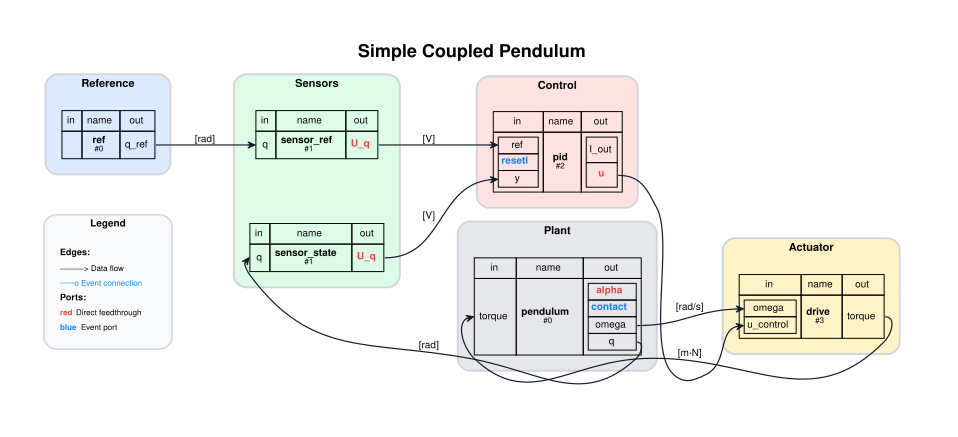

In [120]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()
visualizer.save("ControlledPendulumSimple.svg")


## Run the Baseline (Wind-Up Demonstration)

When the pendulum hits the wall, the reference may continue to demand motion that is physically impossible. This creates sustained error and causes **integrator wind-up** inside the PID controller.

After the reference crosses the wall again, the wound-up integrator can prevent the controller from re-tracking the trajectory cleanly.


In [121]:
system.run(t0=0.0, tf=10.0, dt=0.01)

In [122]:
history = system.get_history()

def get_series(history, comp: str, port: str):
    t, data = history.get(comp)
    return t, np.asarray(data[port])


t_ref, q_ref = get_series(history, "ref", "q_ref")
t_q, q = get_series(history, "pendulum", "q")
t_u, u = get_series(history, "pid", "u")
t_I_out, I_out = get_series(history, "pid", "I_out")

### Baseline Results

In the plots below, pay special attention to the PID integrator output `I_out`. A growing integral term during wall contact is a strong indicator of wind-up.


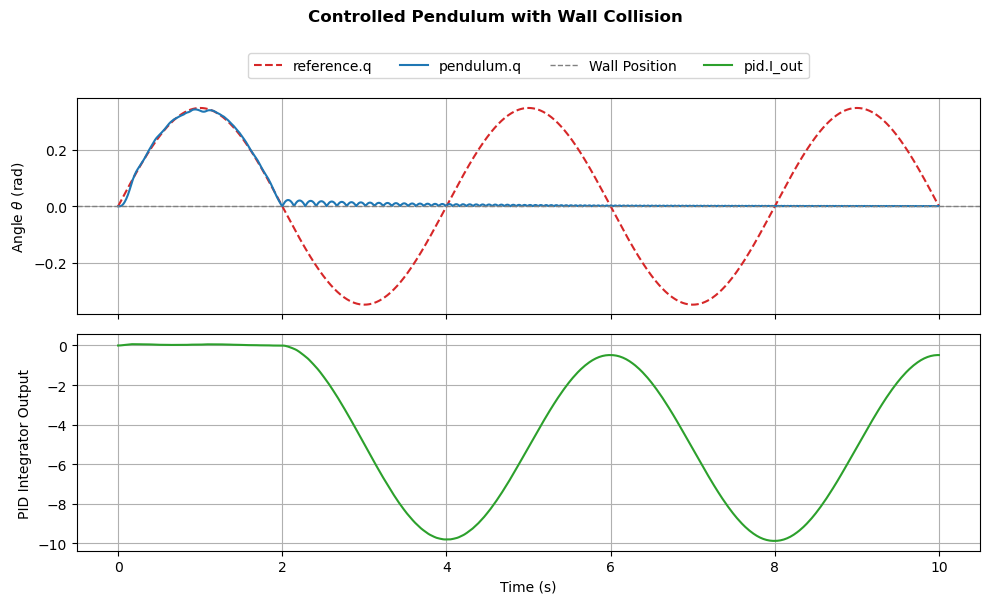

In [123]:
history = system.get_history()

ref_history = history["ref"]
pid_history = history["pid"]
pendulum_history = history["pendulum"]


t_ref, data = ref_history
q_ref = data["q_ref"]
t_pendulum, data = pendulum_history
q_pendulum = data["q"]
t_pid, data = pid_history
i_out = data["I_out"]


fig, axs = plt.subplots(ncols=1, nrows=2, sharex=True)
fig.set_size_inches(10, 6)

fig.suptitle(r"Controlled Pendulum with Wall Collision", fontweight="bold", y=1)

(s1,) = axs[0].plot(t_ref, q_ref, label="reference.q", color="tab:red", linestyle="--")
(s2,) = axs[0].plot(t_pendulum, q_pendulum, label="pendulum.q", color="tab:blue")
s3 = axs[0].axhline(0, label="Wall Position", color="gray", linestyle="--", linewidth=1)
axs[0].set_ylabel(r"Angle $\theta$ (rad)")
axs[0].grid()

(s4,) = axs[1].plot(t_pid, i_out, label="pid.I_out", color="tab:green")
axs[1].set_ylabel("PID Integrator Output")
axs[1].set_xlabel("Time (s)")
axs[1].grid()

handles = [s1, s2, s3, s4]
axs[0].legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 1.15), ncols=4)

plt.tight_layout()
plt.show()

## Hybrid Fix: Reset the PID on Wall Contact

To address wind-up, we introduce a **hybrid mechanism**:

- detect the wall contact as a state event on the pendulum
- propagate the event to the controller
- reset the PID integrator when the wall is hit

This keeps the controller responsive once the reference trajectory becomes feasible again.


## Modify the FMU Components

### Extend Components With Event Ports and Handling

We wrap the pendulum and PID FMUs in lightweight subclasses to add event-aware behavior:

- the pendulum gains an event input `omega_invert` (used to model the bounce)
- the PID listens for a `wall_hit` event and toggles `resetI`

These extensions keep the rest of the system wiring unchanged.


In [124]:
from syssimx.core import PortSpec, PortType

class Pendulum(FMUComponent):
    def __init__(self, name, group="Plant"):
        super().__init__(name, fmu_paths['Pendulum_Euler'], group)
        self.input_specs.update({"omega_invert": PortSpec("omega_invert", PortType.EVENT, "in")})
        self.solver = "Euler"

    def _do_step_internal(self, t, dt):
        t_right = t + dt
        while t < t_right:
            step_size = min(1e-4, t_right - t)
            super()._do_step_internal(t, step_size)
            t += step_size

    def snapshot_state(self):
        state = {"mode": "EQB"}
        if self.solver == "Euler":
            state["fmu_state"] = self._instance.getFMUState()
        elif self.solver == "Cvode":
            current_state = super().get_state()
            state.update(current_state)
        return state

    def restore_state(self, snapshot, t):
        if snapshot.get("mode", "") != "EQB":
            raise ValueError(
                f"[{self.name}] Incompatible snapshot mode, got '{snapshot.get('mode', '')}'."
            )
        self.t = t
        if self.solver == "Euler":
            self._instance.setFMUState(snapshot["fmu_state"])
        elif self.solver == "Cvode":
            q0 = snapshot["q"]["value"]
            omega0 = snapshot["omega"]["value"]
            self._instance.reset()
            self._instance.instantiate()
            self._instance.setupExperiment(startTime=t)
            self._instance.enterInitializationMode()
            self.set_parameters(**{"q0": q0, "omega0": omega0})
            self._apply_parameters_starts()
            self._apply_input_starts()
            self._instance.exitInitializationMode()
        self._update_output_states(t)
        self._record_outputs(t)

    # Handle events: invert omega on wall hit
    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        restitution = 1
        output = self.get_outputs()
        q0 = output["q"].magnitude
        omega0 = -restitution * output["omega"].magnitude

        self._instance.reset()
        self._instance.instantiate()
        self._instance.setupExperiment(startTime=t)
        self._instance.enterInitializationMode()
        self.set_parameters(**{"q0": q0, "omega0": omega0})
        self._apply_parameters_starts()
        self._apply_input_starts()
        self._instance.exitInitializationMode()

    def _update_output_states(
        self, t: float | None = None, event_names: list[str] | None = []
    ):
        super()._update_output_states(t)
        if event_names:
            for event_name in event_names:
                if event_name in self.output_specs.keys():
                    self.outputs[event_name].set(value=True, t=t)
        else:
            for out_port in self.outputs.values():
                if out_port.spec.type == PortType.EVENT:
                    out_port.set(value=False, t=t)


In [125]:
class PID(FMUComponent):
    """FMU-based PID controller component with integrator reset on events."""

    def __init__(self, name, group="Controller"):
        super().__init__(name, fmu_paths['PID_Continuous_Euler'], group)

    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0)  # Perform a step to apply the resetI input
        self.set_inputs({"resetI": False})

In [126]:
ref = FMUComponent(name="ref", fmu_path=fmu_paths["Reference"], group="Reference")
sensor_ref = FMUComponent(name="sensor_ref", fmu_path=fmu_paths["AngleEncoder"], group="Sensors")
sensor_state = FMUComponent(name="sensor_state", fmu_path=fmu_paths["AngleEncoder"], group="Sensors")
pid = PID(name='pid')
drive = FMUComponent(name="drive", fmu_path=fmu_paths["Drive"], group="Actuator")
pendulum = Pendulum(name='pendulum')

components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

### Register a Wall-Contact Event Indicator

We define a zero-crossing indicator for `q - 0` and register it on the pendulum. A negative direction (`-1`) detects crossings from positive angle toward the wall.


In [127]:
def wall_contact_indicator(comp: Pendulum) -> float:
    theta = comp.get_outputs()["q"]
    threshold = np.deg2rad(0)  # 0 degrees in radians
    return theta - threshold

pendulum.add_event_indicator("wall_hit", wall_contact_indicator, -1)

### Route the Event to the Plant and Controller

We connect the detected `wall_hit` event to two destinations:

- the pendulum itself, to trigger the bounce logic
- the PID controller, to reset the integrator


In [128]:
from syssimx.system.connection import EventConnection

event_connection_1 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)

event_connection_2 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pid.name,
    dst_port=pid.input_specs["resetI"].name,
)

connections = [c1, c2, c3, c4, c5, c6, c7]
event_connections = [event_connection_1, event_connection_2]

## Build and Initialize the Hybrid System

The hybrid system uses the same continuous connections plus the new event connections.


In [129]:
hybrid_system = System(name="Simple Coupled Pendulum Hybrid")

for comp in components:
    hybrid_system.add_component(comp)

for conn in connections:
    hybrid_system.add_connection(conn)

for event_conn in event_connections:
    hybrid_system.add_event_connection(event_conn)

hybrid_system.initialize(t0=0.0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


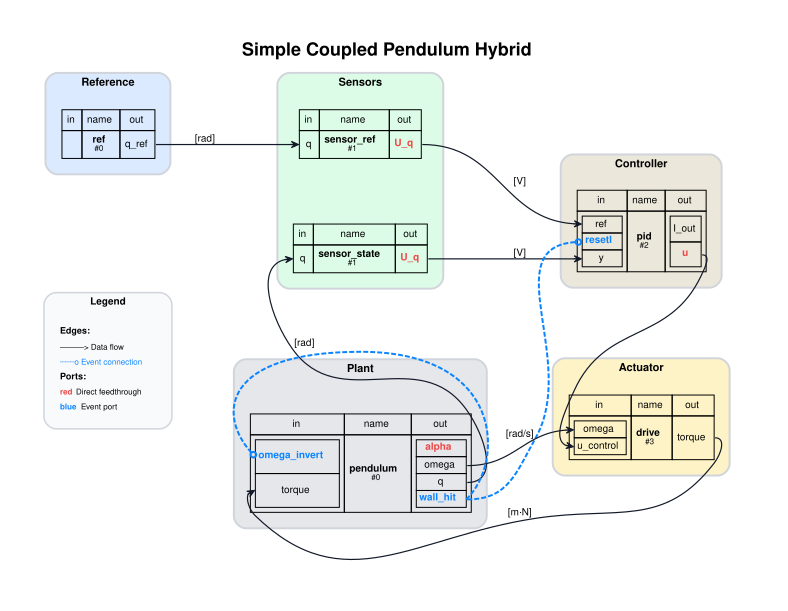

In [130]:
visualizer = SystemGraphVisualizer(hybrid_system)
visualizer.visualize()
visualizer.save("ControlledPendulumSimpleHybrid.svg")

## Run the Hybrid Simulation (With Reset)

Now the controller will reset its integrator at each wall contact event.


In [131]:
hybrid_system.algorithm.verbose = False
hybrid_system.run(t0=0.0, tf=10.0, dt=0.01)

## Hybrid Results and Interpretation


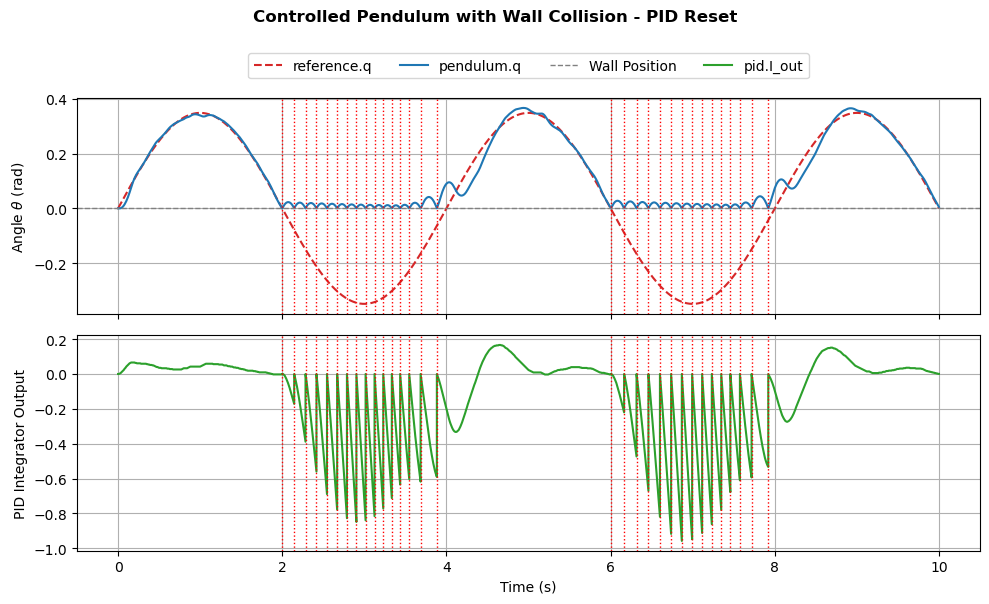

In [132]:
history = hybrid_system.get_history()

ref_history = history["ref"]
pid_history = history["pid"]
pendulum_history = history["pendulum"]
event_history = history["Events"]

event_times = event_history[("pendulum", "wall_hit")]

t_ref, data = ref_history
q_ref = data["q_ref"]
t_pendulum, data = pendulum_history
q_pendulum = data["q"]
t_pid, data = pid_history
i_out = data["I_out"]

event_times = [et.t for et in event_times]

fig, axs = plt.subplots(ncols=1, nrows=2, sharex=True)
fig.set_size_inches(10, 6)

fig.suptitle(r"Controlled Pendulum with Wall Collision - PID Reset", fontweight="bold", y=1)

(s1,) = axs[0].plot(t_ref, q_ref, label="reference.q", color="tab:red", linestyle="--")
(s2,) = axs[0].plot(t_pendulum, q_pendulum, label="pendulum.q", color="tab:blue")
s3 = axs[0].axhline(0, label="Wall Position", color="gray", linestyle="--", linewidth=1)
axs[0].set_ylabel(r"Angle $\theta$ (rad)")
axs[0].grid()

(s4,) = axs[1].plot(t_pid, i_out, label="pid.I_out", color="tab:green")
axs[1].set_ylabel("PID Integrator Output")
axs[1].set_xlabel("Time (s)")
axs[1].grid()

handles = [s1, s2, s3, s4]
axs[0].legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 1.15), ncols=4)

for t_event in event_times:
    axs[0].axvline(t_event, color="red", linestyle=":", linewidth=1)
    axs[1].axvline(t_event, color="red", linestyle=":", linewidth=1)

plt.tight_layout()
plt.show()

We can see in the figure above that the integrator output `I_out` is reset to zero at each wall contact, preventing wind-up.

As a result, the pendulum is able to re-track the reference trajectory more effectively after each collision.

This demonstrates the effectiveness of incorporating hybrid mechanisms into the control strategy for systems with discontinuous dynamics.